# FFT image compression and analysis

PHYS 2260 \
Charles Wang

This notebook implements very rudimentary image compression using the Fast Fourier Transform (FFT). I then perform two different analysis methods with the algorithm. First, I use Newton's method to derive the most optimal Fourier coefficient threshold for a given energy retention level. Second, I graph the compression ratio against the peak signal-to-noise ratio (PSNR) to visualize the quality-compression tradeoff.

**Scientific question:** how does the removal of high-frequency Fourier coefficients affect the final image quality, and what is the best threshold that balances compression and visuals?

## Code

### Global imports and settings

In [54]:
import numpy as np
from scipy import fft
from PIL import Image
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from typing import Tuple, List

np.set_printoptions(precision=4, suppress=True)

### Load and preprocess image

In [55]:
def load_and_preprocess_image(
    image_path: str, resize_to: Tuple[int, int] = (256, 256)
) -> np.ndarray:
    img = Image.open(image_path).convert("L")

    # Resize image to standard dimensions for processing
    img = img.resize(resize_to, Image.Resampling.LANCZOS)

    # Convert to numpy array and normalize to [0, 1]
    img_array: np.ndarray = np.asarray(img, dtype=np.float64) / 255.0

    return img_array


# Change this line to update the test image to use
test_image_path = "test_images/otherworld.jpg"

# Load and preprocess the image
image_data = load_and_preprocess_image(test_image_path, resize_to=(256, 256))

### Apply FFT

Regular FFT works on one-dimensional data, but it turns out that FFT can be applied independently to every row and column in an image. This is essentially what `fft2` does.

Next, we calculate the "energy" in the given image, which is the metric that we'll use to determine what our threshold for the Fourier coefficients will be.

In [56]:
def apply_2d_fft(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    fft_raw = fft.fft2(image)

    # Shift zero-frequency component to center
    fft_coeffs: np.ndarray = fft.fftshift(fft_raw)

    # Compute magnitude spectrum, and convert to a log scale for
    # better visualization (add 1 to avoid log(0))
    magnitude_spectrum: np.ndarray = np.abs(fft_coeffs)
    log_magnitude: np.ndarray = np.log1p(magnitude_spectrum)

    return fft_coeffs, magnitude_spectrum, log_magnitude


# Apply FFT to the image
fft_coeffs, magnitude_spectrum, log_magnitude = apply_2d_fft(image_data)

### Use Newton's Method for optimizing the coefficient threshold

We find the optimal threshold such that retained energy equals a target percentage. I did some tests and 95% energy retention seems to be a good goal to target.

Note that because Newton's method utilizes the derivative, the threshold cannot simply be a harsh cutoff. I did some research and smoothing the threshold off lets the algorithm stay stable.

In [ ]:
def energy_retention_function(
    threshold: float, magnitude_spectrum: np.ndarray, target_retention: float
) -> float:
    coefficients_above_threshold = magnitude_spectrum[magnitude_spectrum >= threshold]

    if len(coefficients_above_threshold) == 0:
        return -target_retention

    # We have to use a smooth threshold in order to let Newton's method work.
    # This is because it allows Newton's method to be differentiable.
    scale = max(float(np.std(magnitude_spectrum)), 1e-12)
    beta = 40.0 / scale
    arg = np.clip(beta * (magnitude_spectrum - threshold), -80.0, 80.0)
    weights = 1.0 / (1.0 + np.exp(-arg))

    energy_retained = np.sum((weights * magnitude_spectrum) ** 2)
    total_energy = np.sum(magnitude_spectrum**2)
    retention_ratio = energy_retained / total_energy

    return retention_ratio - target_retention


def energy_retention_derivative(
    threshold: float, magnitude_spectrum: np.ndarray
) -> float:
    """
    Numerical derivative of energy retention function using central difference.
    """
    scale = max(float(np.std(magnitude_spectrum)), 1e-12)
    beta = 40.0 / scale
    arg = np.clip(beta * (magnitude_spectrum - threshold), -80.0, 80.0)
    weights = 1.0 / (1.0 + np.exp(-arg))
    dweights_dT = -beta * weights * (1.0 - weights)

    total_energy = np.sum(magnitude_spectrum**2)
    d_energy_retained_dT = np.sum(2.0 * weights * dweights_dT * (magnitude_spectrum**2))

    derivative_val = d_energy_retained_dT / total_energy
    return derivative_val if abs(derivative_val) > 1e-12 else -1e-12


def find_optimal_threshold(
    magnitude_spectrum: np.ndarray,
    target_retention: float,
    initial_guess: float | None = None,
) -> Tuple[float, dict]:
    """
    Use Newton's Method only to find optimal threshold for energy retention.
    """
    if initial_guess is None:
        percentile = (1.0 - target_retention) * 100
        percentile = np.clip(percentile, 5, 95)
        initial_guess = float(np.percentile(magnitude_spectrum, percentile))

    def residual(T: float) -> float:
        return energy_retention_function(T, magnitude_spectrum, target_retention)

    def derivative(T: float) -> float:
        return energy_retention_derivative(T, magnitude_spectrum)

    lower_bound = float(np.percentile(magnitude_spectrum, 0.1))
    upper_bound = float(np.percentile(magnitude_spectrum, 99.9))

    # Retry with multiple initial guesses to somewhat increase chance of success
    initial_guesses = [
        initial_guess,
        float(np.percentile(magnitude_spectrum, 10)),
        float(np.percentile(magnitude_spectrum, 25)),
        float(np.percentile(magnitude_spectrum, 50)),
        float(np.percentile(magnitude_spectrum, 75)),
        float(np.percentile(magnitude_spectrum, 90)),
    ]

    optimal_threshold = None
    last_error: Exception | None = None

    def damped_newton(
        start: float, max_iterations: int = 120, tolerance: float = 1e-8
    ) -> float:
        x = float(np.clip(start, lower_bound, upper_bound))
        span = upper_bound - lower_bound
        best_x = x
        best_abs_f = abs(residual(x))

        for _ in range(max_iterations):
            f_x = residual(x)
            abs_f_x = abs(f_x)
            if abs_f_x < best_abs_f:
                best_abs_f = abs_f_x
                best_x = x
            if abs_f_x < tolerance:
                return x

            df_x = derivative(x)
            if abs(df_x) < 1e-14:
                # Newton's method has issues when the slope is too flat, because then
                # we are getting close to dividing by zero. If this is the case, then
                # I manually add a little offset so that we don't get errors.
                x = float(np.clip(x + 1e-4 * span, lower_bound, upper_bound))
                continue

            step = f_x / df_x
            max_step = 0.25 * span
            step = float(np.clip(step, -max_step, max_step))

            x_new = float(np.clip(x - step, lower_bound, upper_bound))
            if x_new == x:
                x = float(np.clip(x + 1e-4 * span, lower_bound, upper_bound))
            else:
                x = x_new

        return best_x

    for guess in initial_guesses:
        try:
            candidate = damped_newton(guess)
            if np.isfinite(candidate):
                optimal_threshold = candidate
                break
        except (RuntimeError, OverflowError, ValueError) as err:
            last_error = err

    if optimal_threshold is None:
        raise RuntimeError("Failed to run Newton's Method!") from last_error

    final_residual = residual(optimal_threshold)
    coefficients_kept = int(np.sum(magnitude_spectrum >= optimal_threshold))
    compression_ratio = 1.0 - (coefficients_kept / magnitude_spectrum.size)

    convergence_info = {
        "final_residual": final_residual,
        "coefficients_kept": coefficients_kept,
        "total_coefficients": magnitude_spectrum.size,
        "compression_ratio": compression_ratio,
        "target_retention": target_retention,
    }

    return optimal_threshold, convergence_info


# This value is adjustable but I like the results I'm getting with 0.95.
target_energy_retention = 0.95
optimal_threshold, convergence_info = find_optimal_threshold(
    magnitude_spectrum, target_retention=target_energy_retention
)

### Filter out high-frequency coefficients and apply IFFT

Now that we've determined the "optimal" threshold, we use it to filter out all Fourier coefficients that don't meet it, and then reconstruct the image. The neat part about FFT is that this is simply applying the inverse Fourier transform to get back the image pixel values.

In [58]:
def reconstruct_image(
    fft_coeffs: np.ndarray, threshold: float
) -> Tuple[np.ndarray, np.ndarray]:
    # Create mask for coefficients above threshold, and apply it
    magnitude = np.abs(fft_coeffs)
    mask: np.ndarray = magnitude >= threshold
    filtered_coeffs = fft_coeffs * mask

    # Store masked spectrum for visualization later
    masked_spectrum: np.ndarray = np.abs(filtered_coeffs)

    # Shift back to standard FFT format, apply IFFT
    filtered_coeffs_unshifted = fft.ifftshift(filtered_coeffs)
    reconstructed_raw = fft.ifft2(filtered_coeffs_unshifted)

    # Clip to valid pixel range [0, 1]
    reconstructed_image: np.ndarray = np.real(reconstructed_raw)
    reconstructed_image = np.clip(reconstructed_image, 0.0, 1.0)

    return reconstructed_image, masked_spectrum


reconstructed_image, masked_spectrum = reconstruct_image(fft_coeffs, optimal_threshold)


### Calculate metrics

To actually measure how effective our compression is, we turn to two metrics that are commonly used in lossy compressions: PSNR and a general compression ratio. We calculate both of those here.

In [59]:
def calculate_metrics(
    original: np.ndarray,
    reconstructed: np.ndarray,
    magnitude_spectrum: np.ndarray,
    threshold: float,
) -> dict:
    # PSNR
    error_power = np.mean((original - reconstructed) ** 2)

    if error_power == 0:
        psnr: float = float("inf")
    else:
        # Assuming pixel values are in [0, 1]
        max_pixel_value = 1.0
        psnr = 20 * np.log10(max_pixel_value / np.sqrt(error_power))

    # Compression metrics
    total_coefficients = magnitude_spectrum.size
    coefficients_kept = np.sum(magnitude_spectrum >= threshold)
    compression_ratio: float = 1.0 - (coefficients_kept / total_coefficients)

    # Energy retention
    mask = magnitude_spectrum >= threshold
    energy_kept = np.sum((magnitude_spectrum * mask) ** 2)
    total_energy = np.sum(magnitude_spectrum**2)
    energy_retention: float = energy_kept / total_energy if total_energy > 0 else 0

    metrics = {
        "psnr": psnr,
        "compression_ratio": compression_ratio,
        "coefficients_kept": coefficients_kept,
        "coefficients_total": total_coefficients,
        "energy_retention": energy_retention,
    }

    return metrics


# Calculate metrics for the optimal compression
optimal_metrics = calculate_metrics(
    image_data, reconstructed_image, magnitude_spectrum, optimal_threshold
)


print(f" - PSNR: {optimal_metrics['psnr']:.4f} dB")
print(f" - Compression ratio: {optimal_metrics['compression_ratio']:.4f}")
print(f" - Energy retention: {optimal_metrics['energy_retention']:.4f}")

 - PSNR: 23.2628 dB
 - Compression ratio: 0.9949
 - Energy retention: 0.9502


### Perform trials across range of thresholds

To generate a graph, we have to run multiple trials are varying thresholds in order to see the relationship between the compression ratio and image quality, which is quantified by PSNR.

In [61]:
num_trials = 20

min_threshold = np.min(magnitude_spectrum) * 0.1
max_threshold = np.percentile(magnitude_spectrum, 95)
thresholds = np.logspace(np.log10(min_threshold), np.log10(max_threshold), num_trials)

trial_results: List[dict] = []
compression_ratios: List[float] = []
psnr_values: List[float] = []

# Run multiple compression trials
for threshold in thresholds:
    # Reconstruct with this threshold
    reconstructed, _ = reconstruct_image(fft_coeffs, threshold)

    # Calculate metrics
    metrics = calculate_metrics(
        image_data, reconstructed, magnitude_spectrum, threshold
    )

    compression_ratios.append(metrics["compression_ratio"])
    psnr_values.append(metrics["psnr"])

    trial_results.append(
        {
            "threshold": threshold,
            "compression_ratio": metrics["compression_ratio"],
            "psnr": metrics["psnr"],
            "energy_retention": metrics["energy_retention"],
        }
    )

compression_ratios_analysis = np.array(compression_ratios)
psnr_values_analysis = np.array(psnr_values)

### Visualize results

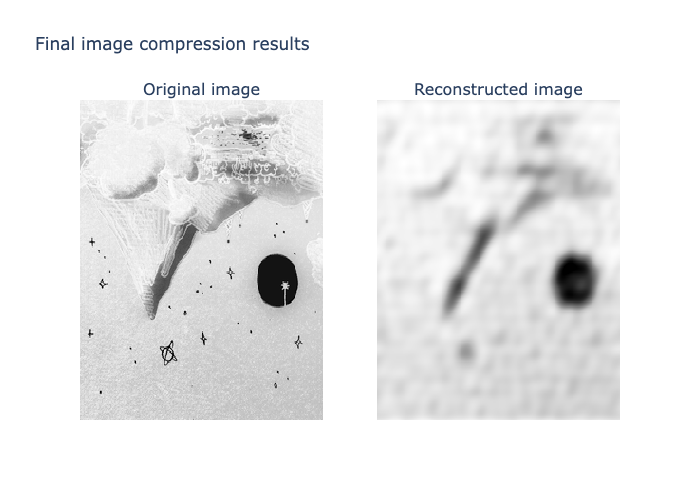

In [70]:
def create_before_after_fig(
    original: np.ndarray,
    log_magnitude: np.ndarray,
    masked_spectrum: np.ndarray,
    reconstructed: np.ndarray,
) -> go.Figure:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Original image", "Reconstructed image"),
        specs=[[{"type": "heatmap"}, {"type": "heatmap"}]],
    )
    fig.add_trace(
        go.Heatmap(z=original, colorscale="Greys", showscale=False, name="Original"),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Heatmap(
            z=reconstructed, colorscale="Greys", showscale=False, name="Reconstructed"
        ),
        row=1,
        col=2,
    )
    fig.update_layout(title_text="Final image compression results", showlegend=False)

    fig.update_xaxes(showticklabels=False)
    fig.update_yaxes(showticklabels=False)

    return fig


create_before_after_fig(
    image_data, log_magnitude, masked_spectrum, reconstructed_image
).show()

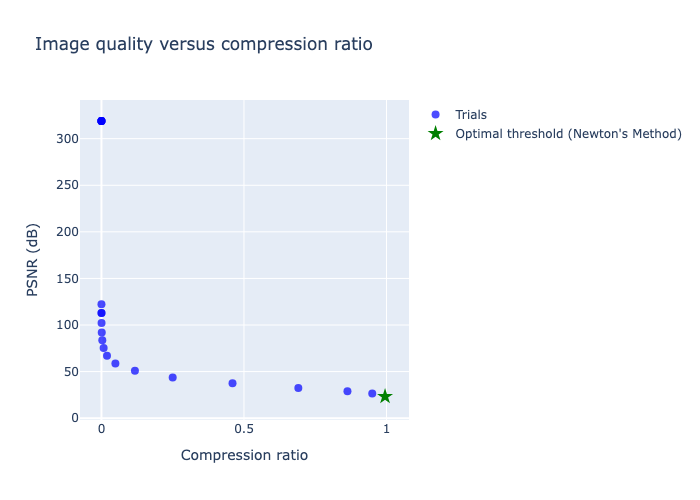

In [74]:
fig_analysis = go.Figure()
fig_analysis.add_trace(
    go.Scatter(
        x=compression_ratios_analysis,
        y=psnr_values_analysis,
        mode="markers",
        name="Trials",
        marker=dict(size=8, color="blue", opacity=0.7),
    )
)
fig_analysis.add_trace(
    go.Scatter(
        x=[optimal_metrics["compression_ratio"]],
        y=[optimal_metrics["psnr"]],
        mode="markers",
        name="Optimal threshold (Newton's Method)",
        marker=dict(size=12, color="green", symbol="star"),
    )
)

fig_analysis.update_layout(
    title="Image quality versus compression ratio",
    xaxis_title="Compression ratio",
    yaxis_title="PSNR (dB)",
)

fig_analysis.show()


## Conclusions

While this may be stating the obvious, I have shown that as the compression ratio increases, the peak signal-to-noise ratio decreases. What does this actually mean? When the compression ratio increases, this implies that more of the higher-frequency Fourier coefficients have been removed from the compressed image. Furthermore, PSNR is a measure of visual quality. Therefore, we can say that removing more data from the image reduces visual quality: in other words, image compression works!

Furthermore, image compression is extremely effective, even using our rudimentary methods. With a compression ratio of 0.5, I was able to keep much of the visual quality in the image.